Attribute Information

id : Unique ID for the customer

Gender : Gender of the customer

Age : Age of the customer

Driving_License 0 : Customer does not have DL, 1 : Customer already has DL

Region_Code : Unique code for the region of the customer

Previously_Insured : 1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance

Vehicle_Age : Age of the Vehicle

Vehicle_Damage :1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past.

Annual_Premium : The amount customer needs to pay as premium in the year

PolicySalesChannel : Anonymized Code for the channel of outreaching to the customer ie. Different Agents, Over Mail, Over Phone, In Person, etc.

Vintage : Number of Days, Customer has been associated with the company

Response : 1 : Customer is interested, 0 : Customer is not interested

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
plt.rcParams["figure.figsize"] = (10,6)
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df1 = pd.read_csv("aug_train.csv")              ## Our data was divided into 3 parts and we brought them together to analyze them properly
df2 = pd.read_csv("aug_test.csv")
df3 = pd.read_csv("sample_submission.csv")

In [4]:
df1   # Train data

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,17163,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,32023,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,87447,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,501933,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0
...,...,...,...,...,...,...,...,...,...,...,...,...
382149,164549,Male,24,1,15.0,0,< 1 Year,Yes,23938.0,152.0,105,0
382150,247064,Male,27,1,28.0,1,< 1 Year,No,336395.0,152.0,144,0
382151,165293,Male,45,1,28.0,0,1-2 Year,Yes,40443.0,26.0,187,0
382152,383241,Female,28,1,28.0,1,< 1 Year,No,25380.0,152.0,208,0


In [5]:
df2 # Test data

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage
0,57782,Female,34,1,39.0,1,1-2 Year,No,38244.0,124.0,146
1,286811,Female,55,1,28.0,0,> 2 Years,Yes,37577.0,122.0,109
2,117823,Male,39,1,28.0,1,1-2 Year,No,24578.0,26.0,63
3,213992,Male,28,1,50.0,1,1-2 Year,No,40507.0,8.0,129
4,324756,Female,24,1,10.0,0,< 1 Year,Yes,36783.0,152.0,201
...,...,...,...,...,...,...,...,...,...,...,...
78268,847,Male,43,1,39.0,0,1-2 Year,Yes,2630.0,124.0,26
78269,417524,Female,21,1,12.0,1,< 1 Year,No,32937.0,152.0,185
78270,188087,Male,48,1,29.0,1,1-2 Year,No,35247.0,124.0,101
78271,215680,Male,64,1,5.0,1,1-2 Year,No,25705.0,26.0,86


In [6]:
df4 = pd.merge(df2, df3)  ## we merged X-test with y-test 
df4

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,57782,Female,34,1,39.0,1,1-2 Year,No,38244.0,124.0,146,0.5
1,286811,Female,55,1,28.0,0,> 2 Years,Yes,37577.0,122.0,109,0.5
2,117823,Male,39,1,28.0,1,1-2 Year,No,24578.0,26.0,63,0.5
3,213992,Male,28,1,50.0,1,1-2 Year,No,40507.0,8.0,129,0.5
4,324756,Female,24,1,10.0,0,< 1 Year,Yes,36783.0,152.0,201,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
78268,847,Male,43,1,39.0,0,1-2 Year,Yes,2630.0,124.0,26,0.5
78269,417524,Female,21,1,12.0,1,< 1 Year,No,32937.0,152.0,185,0.5
78270,188087,Male,48,1,29.0,1,1-2 Year,No,35247.0,124.0,101,0.5
78271,215680,Male,64,1,5.0,1,1-2 Year,No,25705.0,26.0,86,0.5


In [7]:
df = pd.concat([df1, df4], ignore_index=True)  ## we have concatenated all test and train data
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0.0
1,17163,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0.0
2,32023,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0.0
3,87447,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0.0
4,501933,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
460422,847,Male,43,1,39.0,0,1-2 Year,Yes,2630.0,124.0,26,0.5
460423,417524,Female,21,1,12.0,1,< 1 Year,No,32937.0,152.0,185,0.5
460424,188087,Male,48,1,29.0,1,1-2 Year,No,35247.0,124.0,101,0.5
460425,215680,Male,64,1,5.0,1,1-2 Year,No,25705.0,26.0,86,0.5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 460427 entries, 0 to 460426
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    460427 non-null  int64  
 1   Gender                460427 non-null  object 
 2   Age                   460427 non-null  int64  
 3   Driving_License       460427 non-null  int64  
 4   Region_Code           460427 non-null  float64
 5   Previously_Insured    460427 non-null  int64  
 6   Vehicle_Age           460427 non-null  object 
 7   Vehicle_Damage        460427 non-null  object 
 8   Annual_Premium        460427 non-null  float64
 9   Policy_Sales_Channel  460427 non-null  float64
 10  Vintage               460427 non-null  int64  
 11  Response              460427 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 42.2+ MB


In [9]:
df.select_dtypes("number")

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,22,1,7.0,1,2630.0,152.0,16,0.0
1,17163,42,1,28.0,0,43327.0,26.0,135,0.0
2,32023,66,1,33.0,0,35841.0,124.0,253,0.0
3,87447,22,1,33.0,0,27645.0,152.0,69,0.0
4,501933,28,1,46.0,1,29023.0,152.0,211,0.0
...,...,...,...,...,...,...,...,...,...
460422,847,43,1,39.0,0,2630.0,124.0,26,0.5
460423,417524,21,1,12.0,1,32937.0,152.0,185,0.5
460424,188087,48,1,29.0,1,35247.0,124.0,101,0.5
460425,215680,64,1,5.0,1,25705.0,26.0,86,0.5


# Gender

In [10]:
df.Gender.value_counts()

Gender
Male      247653
Female    212774
Name: count, dtype: int64

In [11]:
male_percent= (df.Gender.loc[(df["Gender"] == "Male")].count() / df['Gender'].count()) *100
male_percent

53.78767969732444

In [12]:
female_percent = 100 - male_percent
female_percent

46.21232030267556

Text(0.5, 1.0, 'Gender')

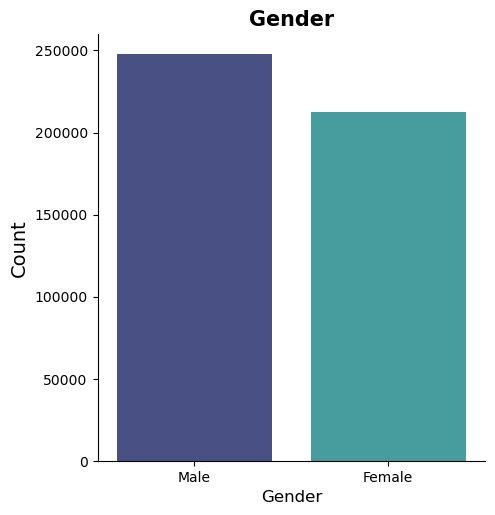

In [13]:
sns.catplot(x="Gender", hue="Gender", kind="count",                      # 
                palette="mako",
                data=df)
plt.xlabel('Gender', fontdict={'fontsize':12})
plt.ylabel('Count',fontdict={'fontsize': 14})
plt.title('Gender', fontdict={'fontsize': 15, 'fontweight':'bold'})

In [14]:
m_yes = df.Response.loc[(df.Gender == "Male") & (df.Response == 1.0)].count() # Those who are male and the answer is yes.
m_yes

38397

In [15]:
f_yes = df.Response.loc[(df.Gender == "Female") & (df.Response == 1.0)].count() # Those who are female and the answer is yes.
f_yes

24204

In [16]:
m_yes_percent= (m_yes / (m_yes + f_yes)) * 100
m_yes_percent

61.33608089327647

In [17]:
f_yes_percent = 100 - m_yes_percent
f_yes_percent

38.66391910672353

** This is very interesting, as you see even the total percentage of gender almost is equal (%53M / %46F) but there is a virtually %50 percent difference between men and women who say "yes".

In [18]:
df["Gender"] = df.Gender.replace("Male", 1)

In [19]:
df["Gender"] = df.Gender.replace("Female", 2)

In [20]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,1,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0.0
1,17163,1,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0.0
2,32023,2,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0.0
3,87447,2,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0.0
4,501933,1,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
460422,847,1,43,1,39.0,0,1-2 Year,Yes,2630.0,124.0,26,0.5
460423,417524,2,21,1,12.0,1,< 1 Year,No,32937.0,152.0,185,0.5
460424,188087,1,48,1,29.0,1,1-2 Year,No,35247.0,124.0,101,0.5
460425,215680,1,64,1,5.0,1,1-2 Year,No,25705.0,26.0,86,0.5


# Vehicle_Age

In [21]:
df.Vehicle_Age.unique()

array(['< 1 Year', '1-2 Year', '> 2 Years'], dtype=object)

In [22]:
df.Vehicle_Age.value_counts()

Vehicle_Age
1-2 Year     240981
< 1 Year     200522
> 2 Years     18924
Name: count, dtype: int64

Text(0.5, 1.0, 'Vehicle_Age')

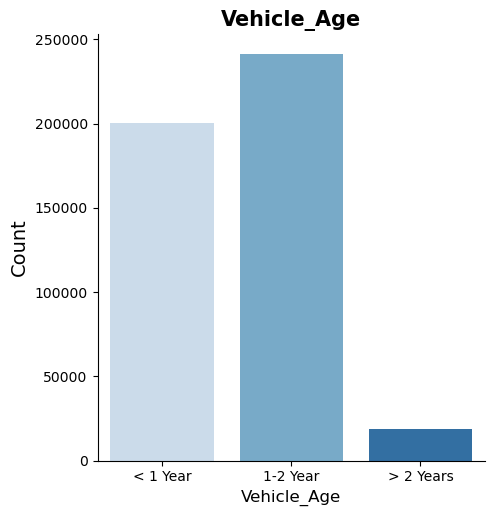

In [23]:
sns.catplot(x="Vehicle_Age", hue="Vehicle_Age", kind="count",                      # 
                palette="Blues",
                data=df)
plt.xlabel('Vehicle_Age', fontdict={'fontsize':12})
plt.ylabel('Count',fontdict={'fontsize': 14})
plt.title('Vehicle_Age', fontdict={'fontsize': 15, 'fontweight':'bold'})

** we don't know exactly the cars' years of more than 3 but the rate of them is very low so we decided to accept them as 3 years.

In [24]:
df.loc[(df.Vehicle_Age == "< 1 Year") , "Vehicle_Age"] = 1

In [25]:
df.loc[(df.Vehicle_Age == "1-2 Year") , "Vehicle_Age"] = 2

In [26]:
df.loc[(df.Vehicle_Age == "> 2 Years") , "Vehicle_Age"] = 3

In [27]:
df.Vehicle_Age.value_counts()

Vehicle_Age
2    240981
1    200522
3     18924
Name: count, dtype: int64

# Vehicle_Damage

In [28]:
df.Vehicle_Damage.value_counts()

Vehicle_Damage
No     239098
Yes    221329
Name: count, dtype: int64

In [29]:
No = df.Vehicle_Damage.loc[(df.Vehicle_Damage == "No") & (df.Response == 1)].count()
No


812

In [30]:
Yes = df.Vehicle_Damage.loc[(df.Vehicle_Damage == "Yes") & (df.Response == 1)].count()  ## We can see how strong the correlation is between 
                                                                                        ## the damaged car and the yes rate.
Yes


61789

Text(0.5, 1.0, 'Vehicle Damage Count')

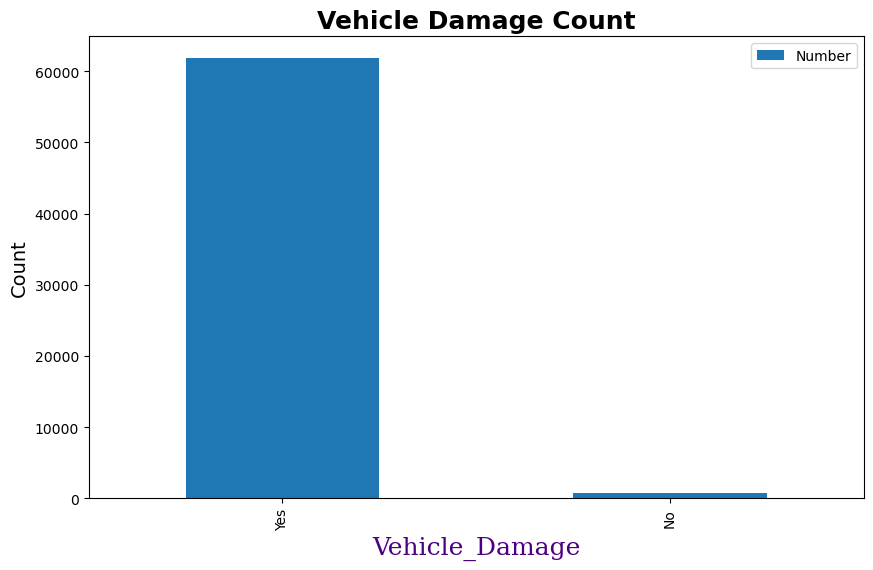

In [31]:
damage = pd.DataFrame({"Vehicle_Damage" :["Yes", "No"], "Number": [61789, 812]})
ax = damage.plot.bar(x= "Vehicle_Damage", y = "Number")

font1 = {"family":"serif", "color":"indigo"}
plt.xlabel("Vehicle_Damage", fontsize = 18, fontdict = font1)
plt.ylabel('Count',fontdict={'fontsize': 14})
plt.title('Vehicle Damage Count', fontdict={'fontsize': 18, 'fontweight':'bold'})

In [32]:
df.loc[(df.Vehicle_Damage == "No") , "Vehicle_Damage"] = 0
df.loc[(df.Vehicle_Damage == "Yes") , "Vehicle_Damage"] = 1

In [33]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,167647,1,22,1,7.0,1,1,0,2630.0,152.0,16,0.0
1,17163,1,42,1,28.0,0,2,1,43327.0,26.0,135,0.0
2,32023,2,66,1,33.0,0,2,1,35841.0,124.0,253,0.0
3,87447,2,22,1,33.0,0,1,0,27645.0,152.0,69,0.0
4,501933,1,28,1,46.0,1,1,0,29023.0,152.0,211,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
460422,847,1,43,1,39.0,0,2,1,2630.0,124.0,26,0.5
460423,417524,2,21,1,12.0,1,1,0,32937.0,152.0,185,0.5
460424,188087,1,48,1,29.0,1,2,0,35247.0,124.0,101,0.5
460425,215680,1,64,1,5.0,1,2,0,25705.0,26.0,86,0.5


<Axes: >

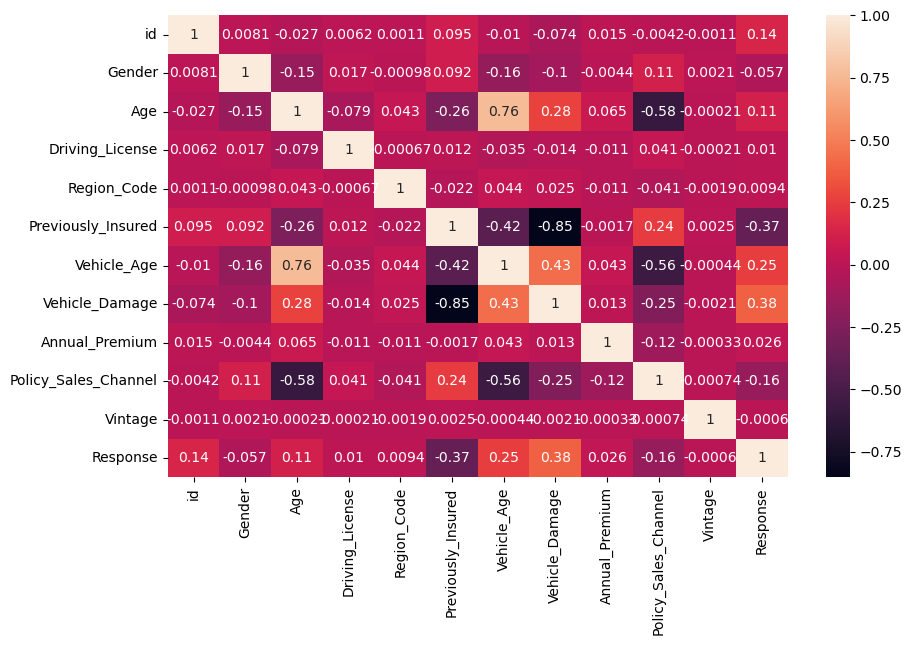

In [34]:
sns.heatmap(df.corr(), annot=True)  ## We want to see the correlation between them.

If we look at correlations between feature and response we can see that correlations between target (response) and id, Vintage, Region_Code, 
Annual_Premium, Driving_License is very low. Therefore we don't need to keep these columns in our dataset.

# Driving_License

In [35]:
df.Driving_License.value_counts()   ## Here too, we can see that there are very few people who do not have a driving license.

Driving_License
1    459537
0       890
Name: count, dtype: int64

Text(0.5, 1.0, 'Driving_License')

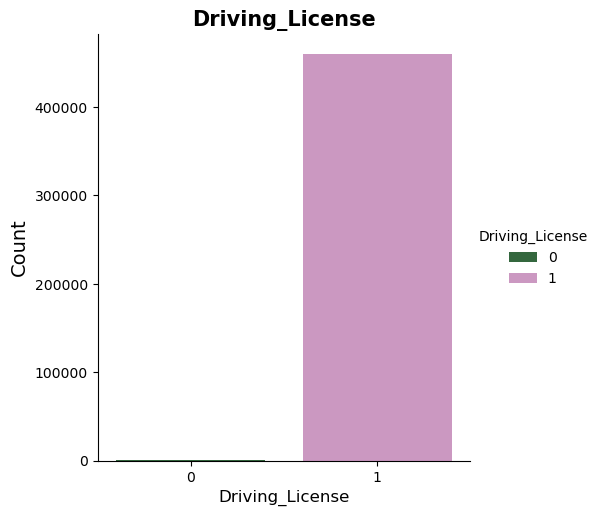

In [36]:
sns.catplot(x="Driving_License", hue="Driving_License", kind="count",                      # 
                palette="cubehelix",
                data=df)
plt.xlabel('Driving_License', fontdict={'fontsize':12})
plt.ylabel('Count',fontdict={'fontsize': 14})
plt.title('Driving_License', fontdict={'fontsize': 15, 'fontweight':'bold'})

# id

In [37]:
df.id.nunique() # returns the number of unique values for each column.
                # If every costumors have different id and id is not repetat we don't need to keep this column.

460427

In [38]:
df = df.drop(["id","Vintage", "Region_Code", "Annual_Premium", "Driving_License"], axis=1)  # We decided to delete all of these rows because their correlation was low.
df  

,Gender,Age,Previously_Insured,Vehicle_Age,Vehicle_Damage,Policy_Sales_Channel,Response
0,1,22,1,1,0,152.0,0.0
1,1,42,0,2,1,26.0,0.0
2,2,66,0,2,1,124.0,0.0
3,2,22,0,1,0,152.0,0.0
4,1,28,1,1,0,152.0,0.0
...,...,...,...,...,...,...,...
460422,1,43,0,2,1,124.0,0.5
460423,2,21,1,1,0,152.0,0.5
460424,1,48,1,2,0,124.0,0.5
460425,1,64,1,2,0,26.0,0.5


<Axes: >

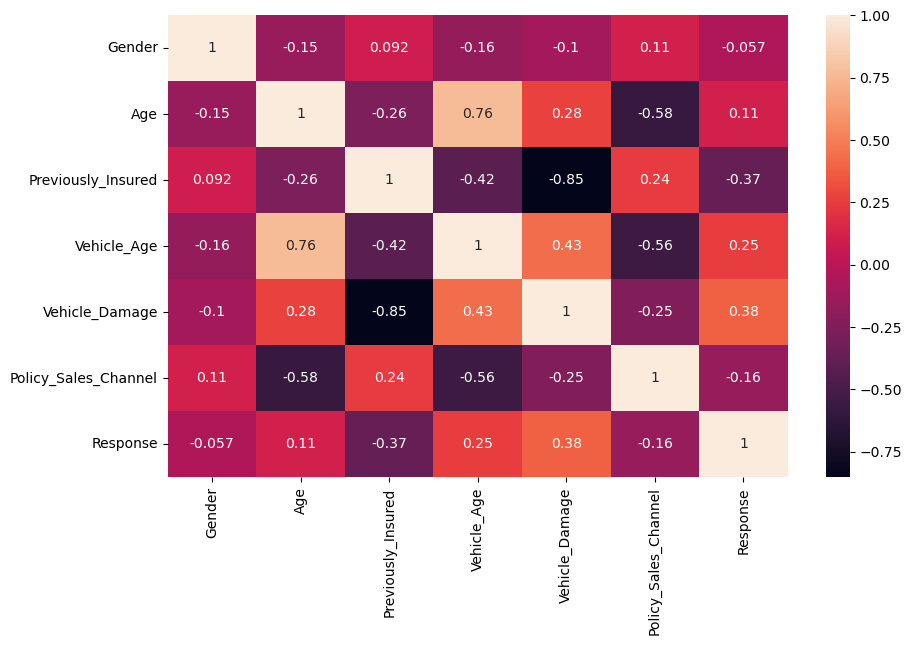

In [39]:
sns.heatmap(df.corr(), annot=True)

# Response

In [40]:
df.Response.unique()

array([0. , 1. , 0.5])

In [41]:
df.Response.value_counts()

Response
0.0    319553
0.5     78273
1.0     62601
Name: count, dtype: int64

Text(0.5, 1.0, 'Response')

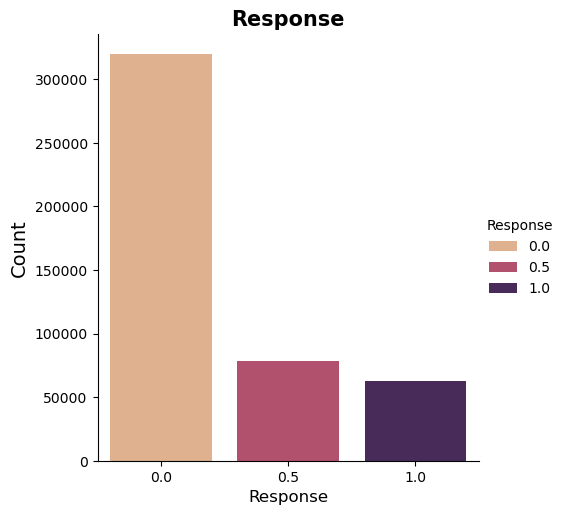

In [42]:
sns.catplot(x="Response", hue="Response", kind="count",                      # 
                palette="flare",
                data=df)
plt.xlabel('Response', fontdict={'fontsize':12})
plt.ylabel('Count',fontdict={'fontsize': 14})
plt.title('Response', fontdict={'fontsize': 15, 'fontweight':'bold'})

In [43]:
df = df.drop(df[df.Response == 0.5].index)  ## We decided to drop the answer "maybe" (0.5) because we didn't accept it as an answer.

In [44]:
df.Response.unique()

array([0., 1.])

Text(0.5, 1.0, 'Response')

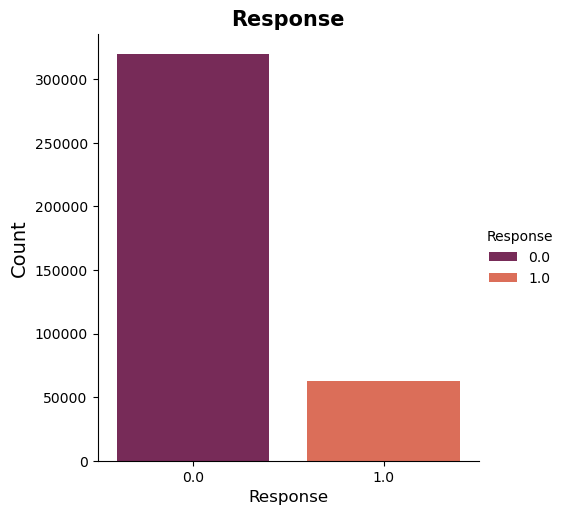

In [45]:
sns.catplot(x="Response", hue="Response", kind="count",                      # 
                palette="rocket",
                data=df)
plt.xlabel('Response', fontdict={'fontsize':12})
plt.ylabel('Count',fontdict={'fontsize': 14})
plt.title('Response', fontdict={'fontsize': 15, 'fontweight':'bold'})

In [46]:
df

,Gender,Age,Previously_Insured,Vehicle_Age,Vehicle_Damage,Policy_Sales_Channel,Response
0,1,22,1,1,0,152.0,0.0
1,1,42,0,2,1,26.0,0.0
2,2,66,0,2,1,124.0,0.0
3,2,22,0,1,0,152.0,0.0
4,1,28,1,1,0,152.0,0.0
...,...,...,...,...,...,...,...
382149,1,24,0,1,1,152.0,0.0
382150,1,27,1,1,0,152.0,0.0
382151,1,45,0,2,1,26.0,0.0
382152,2,28,1,1,0,152.0,0.0


# Age

In [47]:
df.Response.value_counts()

Response
0.0    319553
1.0     62601
Name: count, dtype: int64

In [48]:
under_30 = df.Age.loc[(df.Age <= 30) & (df.Response == 1.0)].count()

In [49]:
over_40 = df.Age.loc[(df.Age >= 40) & (df.Response == 1.0)].count()

Text(0.5, 1.0, 'Age Preference')

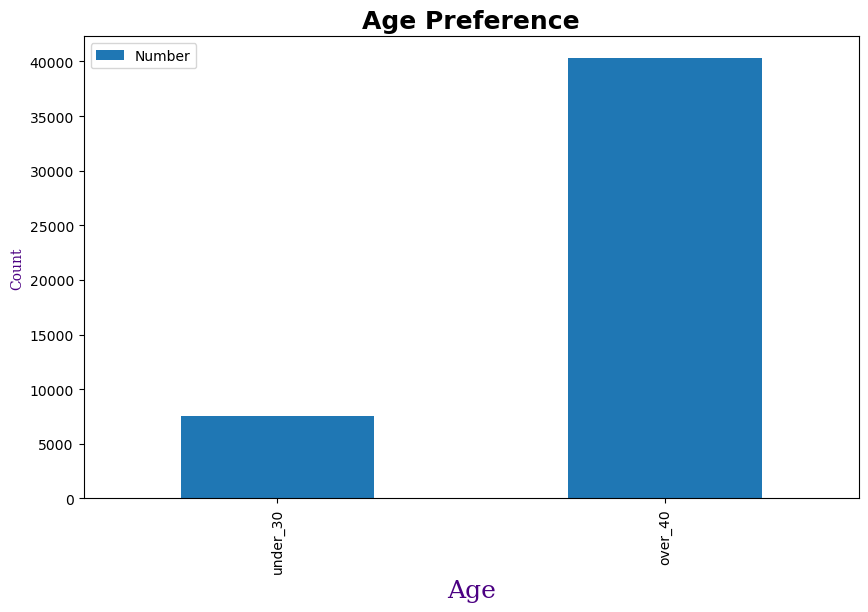

In [50]:
age_pref = pd.DataFrame({"age_pref" :["under_30", "over_40"], "Number": [7531, 40286]})
ax = age_pref.plot.bar(x= "age_pref", y = "Number")

font1 = {"family":"serif", "color":"indigo"}
plt.xlabel("Age", fontsize = 18, fontdict = font1)
plt.ylabel('Count',fontdict=font1)
plt.title('Age Preference', fontdict={'fontsize': 18, 'fontweight':'bold'})

## We can see how the number of people under the age of 30 saying yes 
## is much lower than those over the age of 40.

## Additional Visualization

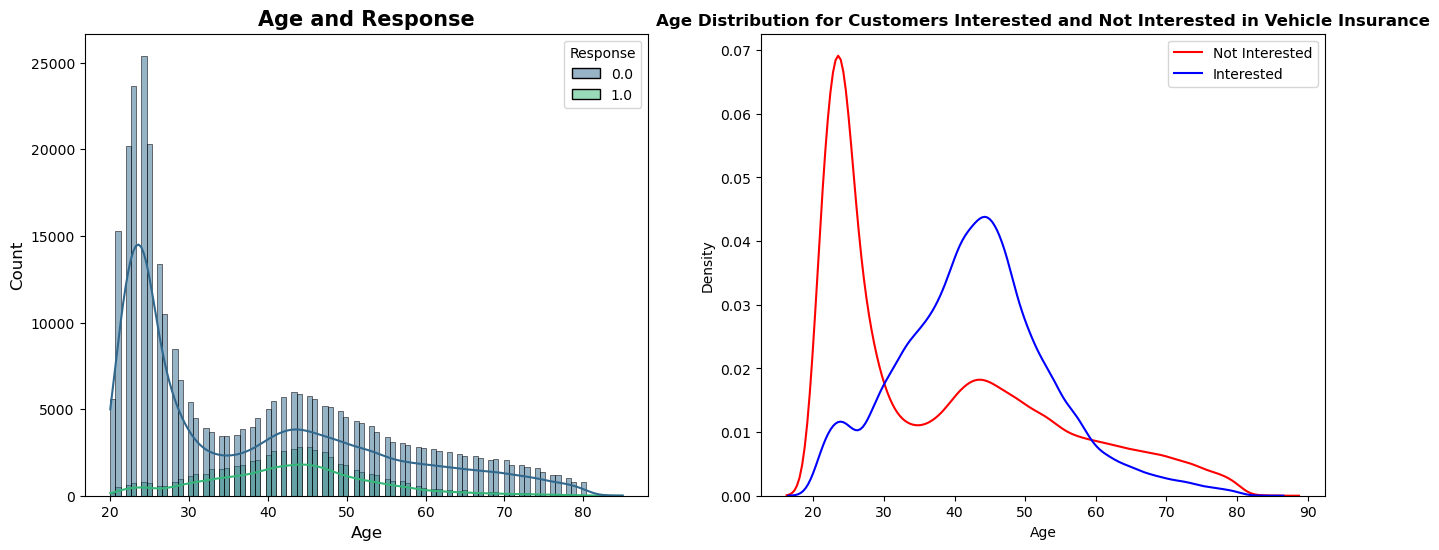

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#create a visualization to show age and response
sns.histplot(data=df, x="Age", hue="Response", kde=True, palette="viridis", ax=ax1)
ax1.set_title("Age and Response", fontsize=15, fontweight="bold")
ax1.set_xlabel("Age", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)

#create a visualization to show Distribution of age for customers who are interested and not interested in vehicle insurance
sns.kdeplot(df[df['Response'] == 0]['Age'], color='red', label='Not Interested', ax=ax2)
sns.kdeplot(df[df['Response'] == 1]['Age'], color='blue', label='Interested', ax=ax2)
ax2.set_xlabel('Age')
ax2.set_ylabel('Density')
ax2.set_title('Age Distribution for Customers Interested and Not Interested in Vehicle Insurance',fontweight="bold")
ax2.legend()
plt.show()

**** As can be seen from the graph, the data set is unbalanced. If we model with this type of data, the result will most likely be negative (0) no matter what we do. Therefore, we need to OVERSAMPLING (SMOTE) the dataset after separating it into independent value and target. 

** So what is OVERSAMPLING (SMOTE)?

By using synthetic data, OVERSAMPLING allows us to balance the ratio of data giving a positive (1) result to data giving a negative (0) result.

## OVERSAMPLING (SMOTE)

In [51]:
X = df.drop('Response',axis=1)
y = df['Response']

In [52]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [53]:
from imblearn.over_sampling import RandomOverSampler

In [54]:
randomsample=  RandomOverSampler()
X_new,y_new=randomsample.fit_resample(X,y)

In [55]:
from collections import Counter

In [56]:
print(f"Data before oversimpling : {Counter(y)}")

Data before oversimpling : Counter({0.0: 319553, 1.0: 62601})


In [57]:
print(f"Data after oversimpling : {Counter(y_new)}")  ## after oversimplig we have balance data which have same number of each response 

Data after oversimpling : Counter({0.0: 319553, 1.0: 319553})


## ## Train | Test Split 

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.3, random_state=101)

In [60]:
scaler = StandardScaler()

In [61]:
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

## Modelling

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
log_model = LogisticRegression()

In [64]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [65]:
y_pred = log_model.predict(X_test_scaled)
y_pred

array([0., 1., 0., ..., 1., 1., 1.])

## Model Performance

In [66]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [67]:
accuracy_score(y_test,y_pred)

0.8135835436964096

In [68]:
recall_score(y_test, y_pred)

0.9817444219066938

In [69]:
f1_score(y_test,y_pred, average = "weighted")

0.8082355009075789